# 04 - CICIDS2017: Multi-Class Benchmark (3 ML Models + 1 DL Model)

## Objective
Evaluate 3 top-tier Machine Learning algorithms and 1 Deep Learning neural network on the clean, balanced CICIDS2017 subset (`CICIDS_clean_subset.parquet`):
- **169,686 rows**, 44 clean features, 7 classes.
- Realistic ~59% Benign : 41% Attacks ratio.

### Models Evaluated:
1. **Random Forest (Balanced)** [ML] — Bagged decision trees with `balanced_subsample` weights
2. **LightGBM (Balanced)** [ML] — Gradient boosted decision trees with `is_unbalance=True`
3. **XGBoost (Balanced)** [ML] — Histogram-based extreme gradient boosting with balanced sample weights
4. **1D-CNN (PyTorch)** [DL] — 1D Convolutional Neural Network for local flow pattern extraction

### Evaluation Metrics:
- **Accuracy** (Unseen test set performance)
- **Weighted F1** (Aggregate multi-class F1 score)
- **Macro F1** (Unweighted mean across all 7 classes, evaluating rare attacks fairly)
- **Train Time (s)** (Computational efficiency)

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Libraries loaded! Compute device for DL: {device}")

Libraries loaded! Compute device for DL: cpu


## 1. Load Clean Subset Dataset & Preprocess (Fast Parquet Loading)

In [2]:
t0 = time.time()
df = pd.read_parquet('../Datasets/CICIDS_clean_subset.parquet')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns in {time.time()-t0:.2f} seconds!")

X = df.drop(columns=['Label'])
y = df['Label']

# Encode Target Labels
label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)
classes = list(label_encoder.classes_)
num_classes = len(classes)
print(f"Target classes ({num_classes}): {classes}")

# Stratified Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=SEED
)

# Standard Scaling with clipping to [-10, 10] (crucial for both ML stability and Neural Networks)
scaler = StandardScaler()
X_train_scaled = np.clip(scaler.fit_transform(X_train), -10, 10)
X_test_scaled = np.clip(scaler.transform(X_test), -10, 10)

# Compute balanced sample weights for XGBoost
sample_weights_train = compute_sample_weight('balanced', y_train)

print(f"Train Shape: {X_train_scaled.shape} | Test Shape: {X_test_scaled.shape}")
print("Preprocessing complete!")

Loaded 169,686 rows and 45 columns in 0.94 seconds!
Target classes (7): ['BENIGN', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'PortScan', 'Web Attack']
Train Shape: (135748, 44) | Test Shape: (33938, 44)
Preprocessing complete!


## 2. Machine Learning Models: Random Forest, LightGBM, and XGBoost

In [3]:
ml_models = {
    "Random Forest (Balanced)": RandomForestClassifier(
        n_estimators=100,
        max_depth=16,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1
    ),
    "LightGBM (Balanced)": LGBMClassifier(
        n_estimators=150,
        max_depth=8,
        learning_rate=0.05,
        is_unbalance=True,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    ),
    "XGBoost (Balanced)": xgb.XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.08,
        tree_method='hist',
        random_state=SEED,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
}

benchmark_results = []
fitted_ml_models = {}

for name, model in ml_models.items():
    print(f"--> Training {name}...")
    start_train = time.time()
    
    if name == "XGBoost (Balanced)":
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_scaled, y_train)
        
    train_time = time.time() - start_train
    fitted_ml_models[name] = model
    
    # Evaluate on test set
    test_preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, test_preds)
    prec = precision_score(y_test, test_preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, test_preds, average='weighted', zero_division=0)
    w_f1 = f1_score(y_test, test_preds, average='weighted', zero_division=0)
    m_f1 = f1_score(y_test, test_preds, average='macro', zero_division=0)
    
    benchmark_results.append({
        "Model": name,
        "Type": "Machine Learning",
        "Accuracy": acc,
        "Weighted F1": w_f1,
        "Macro F1": m_f1,
        "Train Time (s)": train_time
    })
    print(f"    Accuracy: {acc:.4f} | Weighted F1: {w_f1:.4f} | Macro F1: {m_f1:.4f} | Time: {train_time:.2f}s")

print("\nAll 3 Machine Learning models trained and evaluated successfully!")

--> Training Random Forest (Balanced)...
    Accuracy: 0.9922 | Weighted F1: 0.9926 | Macro F1: 0.9579 | Time: 5.11s
--> Training LightGBM (Balanced)...
    Accuracy: 0.9987 | Weighted F1: 0.9987 | Macro F1: 0.9931 | Time: 5.55s
--> Training XGBoost (Balanced)...
    Accuracy: 0.9980 | Weighted F1: 0.9980 | Macro F1: 0.9887 | Time: 8.65s

All 3 Machine Learning models trained and evaluated successfully!


## 3. Deep Learning Architecture: 1D-CNN in PyTorch

In [4]:
# Prepare PyTorch Tensors and DataLoaders
BATCH_SIZE = 512

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

criterion = nn.CrossEntropyLoss()

def predict_dl(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for bx, _ in loader:
            bx = bx.to(device)
            preds = torch.argmax(model(bx), dim=1).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)

### 1D-CNN Architecture (Flow Convolution)

In [5]:
class Fast1DCNN(nn.Module):
    def __init__(self, in_features=44, num_classes=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, num_classes)
        )
        
    def forward(self, x):
        return self.net(x.unsqueeze(1))

cnn_model = Fast1DCNN(in_features=44, num_classes=num_classes).to(device)
print(cnn_model)

Fast1DCNN(
  (net): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): AdaptiveAvgPool1d(output_size=1)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=64, out_features=32, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=7, bias=True)
  )
)


### Train & Evaluate 1D-CNN

In [6]:
def train_dl_model(model, train_loader, test_loader, criterion, epochs=8, lr=0.003):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)
    
    best_macro_f1 = 0.0
    best_weights = None
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(by)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation
        model.eval()
        all_preds, all_targets = [], []
        with torch.no_grad():
            for bx, by in test_loader:
                bx = bx.to(device)
                preds = torch.argmax(model(bx), dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_targets.extend(by.numpy())
                
        val_acc = accuracy_score(all_targets, all_preds)
        val_macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
        scheduler.step(val_macro_f1)
        
        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            best_weights = model.state_dict().copy()
            
        print(f"Epoch {epoch:02d}/{epochs:02d} | Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f} | Val Macro F1: {val_macro_f1:.4f}")
        
    total_train_time = time.time() - start_time
    model.load_state_dict(best_weights)
    return model, total_train_time

print("--> Training Fast 1D-CNN...")
cnn_model, cnn_train_time = train_dl_model(cnn_model, train_loader, test_loader, criterion, epochs=8, lr=0.003)

# Evaluate 1D-CNN
cnn_test_preds = predict_dl(cnn_model, test_loader)
cnn_acc = accuracy_score(y_test, cnn_test_preds)
cnn_wf1 = f1_score(y_test, cnn_test_preds, average="weighted", zero_division=0)
cnn_mf1 = f1_score(y_test, cnn_test_preds, average="macro", zero_division=0)

benchmark_results.append({
    "Model": "1D-CNN",
    "Type": "Deep Learning",
    "Accuracy": cnn_acc,
    "Weighted F1": cnn_wf1,
    "Macro F1": cnn_mf1,
    "Train Time (s)": cnn_train_time
})
print(f"1D-CNN - Accuracy: {cnn_acc:.4f} | Weighted F1: {cnn_wf1:.4f} | Macro F1: {cnn_mf1:.4f} | Time: {cnn_train_time:.1f}s")

--> Training Fast 1D-CNN...
Epoch 01/08 | Loss: 0.6048 | Val Acc: 0.8901 | Val Macro F1: 0.5010
Epoch 02/08 | Loss: 0.2615 | Val Acc: 0.9187 | Val Macro F1: 0.5228
Epoch 03/08 | Loss: 0.2058 | Val Acc: 0.9114 | Val Macro F1: 0.6365
Epoch 04/08 | Loss: 0.1826 | Val Acc: 0.8012 | Val Macro F1: 0.3698
Epoch 05/08 | Loss: 0.1611 | Val Acc: 0.9474 | Val Macro F1: 0.7424
Epoch 06/08 | Loss: 0.1499 | Val Acc: 0.9309 | Val Macro F1: 0.6191
Epoch 07/08 | Loss: 0.1376 | Val Acc: 0.9020 | Val Macro F1: 0.6282
Epoch 08/08 | Loss: 0.1257 | Val Acc: 0.9349 | Val Macro F1: 0.7322
1D-CNN - Accuracy: 0.9349 | Weighted F1: 0.9271 | Macro F1: 0.7322 | Time: 47.2s


## 4. Multi-Model Comparison Matrix & Visualizations

,Model,Type,Accuracy,Weighted F1,Macro F1,Train Time (s)
0,Random Forest (Balanced),Machine Learning,0.992162,0.992643,0.957925,5.111553
1,LightGBM (Balanced),Machine Learning,0.998733,0.998732,0.993097,5.550290
2,XGBoost (Balanced),Machine Learning,0.998026,0.998043,0.988652,8.654882
3,1D-CNN,Deep Learning,0.934881,0.927135,0.732246,47.223707


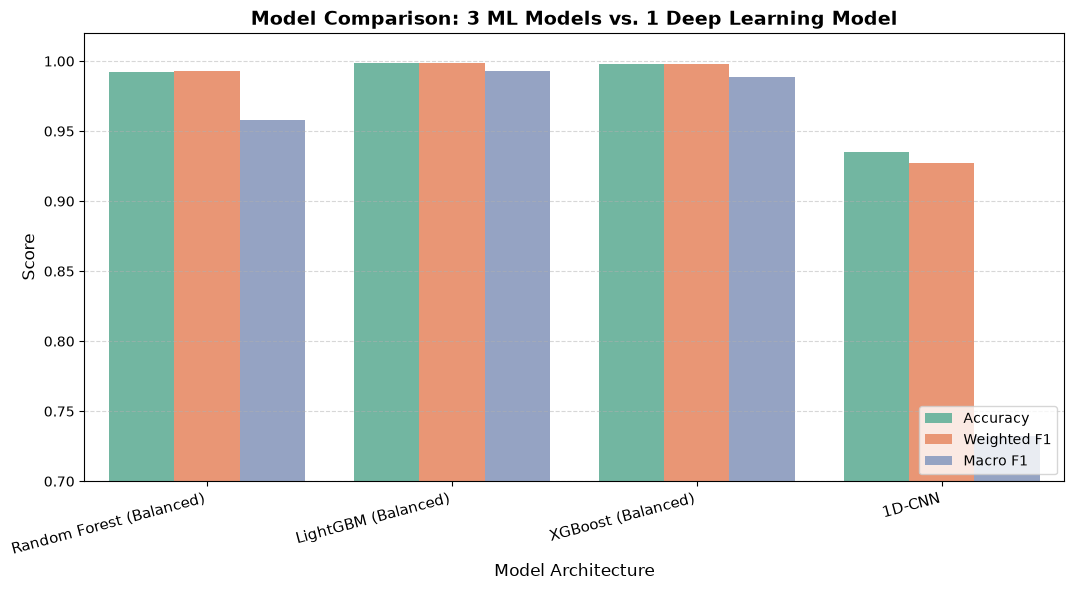

In [7]:
comparison_df = pd.DataFrame(benchmark_results)
display(comparison_df.style.highlight_max(subset=["Accuracy", "Weighted F1", "Macro F1"], color="lightgreen")
                           .highlight_min(subset=["Train Time (s)"], color="lightblue"))

# Visualization: Accuracy, Weighted F1, Macro F1 across 3 ML + 1 DL models
plt.figure(figsize=(11, 6))
melted = comparison_df.melt(id_vars=["Model", "Type"], value_vars=["Accuracy", "Weighted F1", "Macro F1"], var_name="Metric", value_name="Score")
sns.barplot(data=melted, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Comparison: 3 ML Models vs. 1 Deep Learning Model", fontsize=14, fontweight="bold")
plt.ylim(0.70, 1.02)
plt.xticks(rotation=15, ha="right", fontsize=11)
plt.xlabel("Model Architecture", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(loc="lower right", frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Detailed Classification Report & Confusion Matrix (Best Model)

=== Best Model Overall (by Macro F1): LightGBM (Balanced) ===

Detailed Per-Class Performance Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     20001
         Bot       0.98      0.99      0.98       287
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00      5000
         DoS       1.00      1.00      1.00      6000
    PortScan       0.99      0.97      0.98       391
  Web Attack       1.00      0.98      0.99       429

    accuracy                           1.00     33938
   macro avg       0.99      0.99      0.99     33938
weighted avg       1.00      1.00      1.00     33938



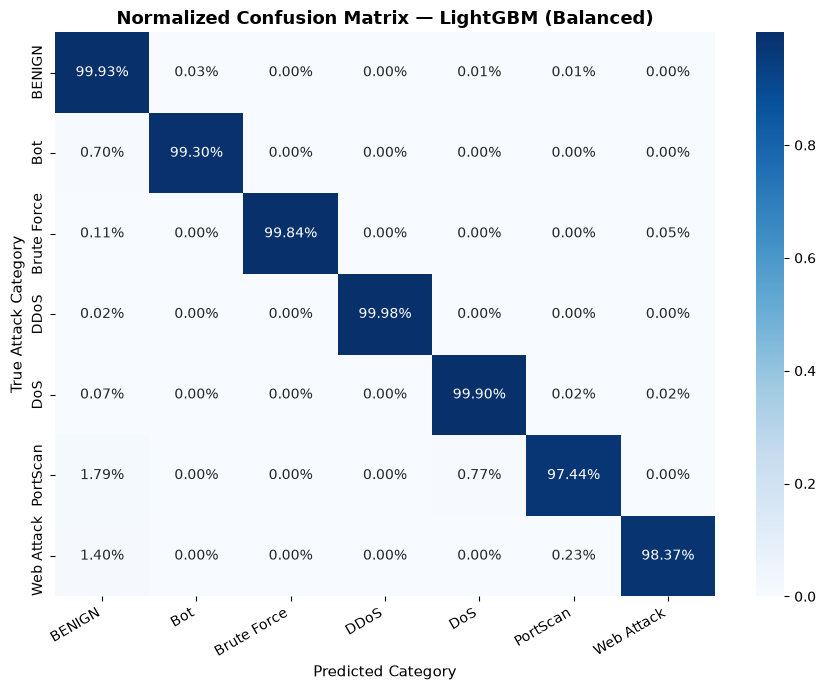

In [8]:
best_idx = comparison_df["Macro F1"].idxmax()
best_name = comparison_df.loc[best_idx, "Model"]
print(f"=== Best Model Overall (by Macro F1): {best_name} ===")

# Determine predictions for best model
if best_name == "Random Forest (Balanced)":
    final_preds = fitted_ml_models["Random Forest (Balanced)"].predict(X_test_scaled)
elif best_name == "LightGBM (Balanced)":
    final_preds = fitted_ml_models["LightGBM (Balanced)"].predict(X_test_scaled)
elif best_name == "XGBoost (Balanced)":
    final_preds = fitted_ml_models["XGBoost (Balanced)"].predict(X_test_scaled)
else:
    final_preds = cnn_test_preds

print("\nDetailed Per-Class Performance Report:")
print(classification_report(y_test, final_preds, target_names=classes, zero_division=0))

# Normalized Confusion Matrix
cm = confusion_matrix(y_test, final_preds, normalize="true")
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title(f"Normalized Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
plt.ylabel("True Attack Category", fontsize=11)
plt.xlabel("Predicted Category", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Save Artifacts to Models Directory

In [9]:
import joblib

os.makedirs("../Models", exist_ok=True)
joblib.dump(scaler, "../Models/final_benchmark_scaler.pkl")
joblib.dump(label_encoder, "../Models/final_benchmark_label_encoder.pkl")
comparison_df.to_csv("../Models/final_3ml_1dl_comparison_benchmark.csv", index=False)
torch.save(cnn_model.state_dict(), "../Models/conv1d_net.pth")
joblib.dump(fitted_ml_models["Random Forest (Balanced)"], "../Models/random_forest_balanced.pkl")
joblib.dump(fitted_ml_models["LightGBM (Balanced)"], "../Models/lightgbm_balanced.pkl")
joblib.dump(fitted_ml_models["XGBoost (Balanced)"], "../Models/xgboost_balanced.pkl")

print("Successfully saved all preprocessors, comparison results, and model weights to ../Models/!")

Successfully saved all preprocessors, comparison results, and model weights to ../Models/!
